In [1]:
# Test Phase1_ReagentEntry in Jupyter notebook
import sys
import os

# Add current directory to path
sys.path.insert(0, '.')

# Import required modules
from mechwolf.DataEntry import create_experiment, launch_reagent_entry

# Create experiment with the filename you specified
experiment_file = "test1.json"
experiment_name = "Phase1 Reagent Entry Test"

print(f"🧪 Creating experiment: {experiment_name}")
print(f"📁 File: {experiment_file}")

# Create the experiment
experiment = create_experiment(experiment_file, experiment_name)

print("✅ Experiment created successfully!")
print("\n🚀 Launching reagent entry GUI...")

# Launch the enhanced reagent entry interface
reagent_gui = launch_reagent_entry(experiment)

print("\n📋 The reagent entry GUI is now active above.")
print("You can now:")
print("• Search for compounds using PubChem")
print("• Add solid and liquid reagents")
print("• View and edit existing reagents")
print("• Manage reaction scale")
print("• Save your work automatically")

# Display current experiment status
print(f"\n📊 Current experiment status:")
chemistry_data = experiment.chemistry.get_data()
solid_count = len(chemistry_data.get("solid_reagents", []))
liquid_count = len(chemistry_data.get("liquid_reagents", []))
print(f"  Solid reagents: {solid_count}")
print(f"  Liquid reagents: {liquid_count}")

🧪 Creating experiment: Phase1 Reagent Entry Test
📁 File: test1.json
✅ Experiment created successfully!

🚀 Launching reagent entry GUI...



📋 The reagent entry GUI is now active above.
You can now:
• Search for compounds using PubChem
• Add solid and liquid reagents
• View and edit existing reagents
• Manage reaction scale
• Save your work automatically

📊 Current experiment status:
  Solid reagents: 1
  Liquid reagents: 1


In [2]:
# Import required modules
import sys
import os

# Add MechWolf to path if needed
sys.path.append('/home/kumar/MechWolf')

import mechwolf as mw
from mechwolf.DataEntry.experimental_metadata import ExperimentalMetadataManager
from mechwolf.DataEntry.Phase2_ApparatusBuilder import (
    launch_tabbed_designer,
    create_tabbed_apparatus_designer,
    print_designer_info
)

print("✅ MechWolf Tabbed Apparatus Designer loaded successfully!")
print("🎯 Ready for focused apparatus development!")

✅ MechWolf Tabbed Apparatus Designer loaded successfully!
🎯 Ready for focused apparatus development!


In [3]:
# Check what designers are available
print_designer_info()

MechWolf Phase 2 Apparatus Builder - Available Designers
📋 Available Designers:
  1. ApparatusBuilderGUI (legacy)
  2. TabbedApparatusDesigner v2 (enhanced modular)

🔧 Tabbed Designer Status: ✅ Available

🚀 Quick Start Options:
  # Legacy GUI (with experiment manager):
  gui = launch_gui(experiment_manager)
  # Tabbed Designer (recommended for development):
  designer = launch_tabbed_designer(experiment_manager)


In [4]:
# Create experimental metadata for this session
experiment_file = "test1.json"
experiment_name = "Tabbed Designer Development Demo"

# Create experiment manager
experiment_manager = ExperimentalMetadataManager(experiment_file, experiment_name)

print(f"📝 Created experiment metadata: {experiment_file}")
print(f"🎯 Experiment: {experiment_name}")
print(f"📊 Metadata file will track all apparatus configurations")

📝 Created experiment metadata: test1.json
🎯 Experiment: Tabbed Designer Development Demo
📊 Metadata file will track all apparatus configurations


In [5]:
# Launch the tabbed apparatus designer with experimental metadata integration
designer = launch_tabbed_designer(experiment_manager)

# The designer will appear below with three tabs:
# - Tab 1: Active Components (Harvard Pumps)
# - Tab 2: Passive Components (Vessels, T-Mixers)
# - Tab 3: Network Connections
# - Bottom: Generated apparatus code

In [6]:
# Generated MechWolf Apparatus Code
import mechwolf as mw
from mechwolf.components.contrib.harvardpump import HarvardSyringePump

# Component Definitions
pump_1 = HarvardSyringePump(name="pump_1", syringe_volume="3 mL", syringe_diameter="10 mm", serial_port="/dev/ttyUSB0")
pump_2 = HarvardSyringePump(name="pump_2", syringe_volume="3 mL", syringe_diameter="10 mm", serial_port="/dev/ttyUSB0")
vessel_1 = mw.Vessel(description="", name="vessel_1")
vessel_2 = mw.Vessel(description="", name="vessel_2")
vessel_3 = mw.Vessel(description="", name="vessel_3")
vessel_4 = mw.Vessel(description="", name="vessel_4")
tmixer_1 = mw.TMixer(name="tmixer_1")
tmixer_2 = mw.TMixer(name="tmixer_2")
tube_1 = mw.Tube(length="1 ft", ID="1/16 in", OD="1/8 in", material="PFA")
tube_2 = mw.Tube(length="1 ft", ID="1/16 in", OD="1/8 in", material="PFA")
tube_3 = mw.Tube(length="1 ft", ID="1/16 in", OD="1/8 in", material="PFA")

# TMixer Connections
tmixer_2 = mw.TMixer(tube_3)

# Apparatus Assembly
A = mw.Apparatus("Generated Apparatus")
A.add(vessel_3, pump_2, tube_1)
A.add(pump_2, tmixer_2, tube_1)
A.add(tmixer_2, vessel_4, tube_3)
A.add(tmixer_1, tmixer_2, tube_2)
A.add(vessel_1, pump_1, tube_1)
A.add(vessel_2, pump_1, tube_1)
A.add(pump_1, tmixer_1, tube_1)

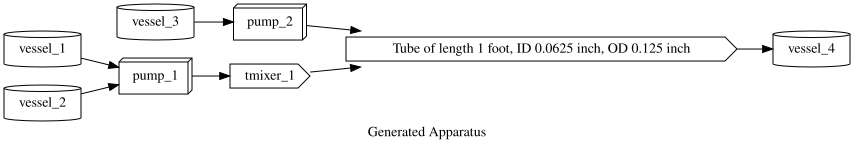

In [7]:
A.visualize()

In [ ]:
# Get current apparatus data from the designer
if 'designer' in locals():
    apparatus_data = designer.get_apparatus_data()
    
    print("📊 Current Apparatus Summary:")
    print(f"  Components: {len(apparatus_data['components'])}")
    print(f"  Connections: {len(apparatus_data['connections'])}")
    
    print("\n🔧 Components:")
    for name, comp_data in apparatus_data['components'].items():
        comp_type = comp_data['component_type']
        print(f"  • {name} ({comp_type})")
    
    print("\n🔗 Connections:")
    for conn_data in apparatus_data['connections']:
        from_comp = conn_data['from_component']
        to_comp = conn_data['to_component']
        tube_type = conn_data['tube_type']
        tube_length = conn_data['tube_length']
        print(f"  • {from_comp} → {to_comp} ({tube_type}, {tube_length})")
else:
    print("🎯 Launch the designer first to see apparatus data")

## Check Experimental Metadata

The apparatus configuration is automatically saved to the experimental metadata system:

In [ ]:
# Check what's stored in the experimental metadata
if 'experiment_manager' in locals():
    print("📝 Experimental Metadata Summary:")
    print(f"  File: {experiment_manager.file_path}")
    print(f"  Experiment: {experiment_manager.get_experiment_name()}")
    
    # Check apparatus section
    try:
        apparatus_config = experiment_manager.apparatus.get_apparatus_configuration()
        if apparatus_config:
            print(f"\n🔧 Apparatus Data Saved:")
            print(f"  Components: {len(apparatus_config.get('components', {}))}")
            print(f"  Connections: {len(apparatus_config.get('connections', []))}")
        else:
            print("\n📋 No apparatus data saved yet")
    except Exception as e:
        print(f"\n⚠️ Could not access apparatus data: {e}")
else:
    print("🎯 Create experiment manager first to see metadata")

## Component Registry Information

The tabbed designer uses a component registry system designed for easy extension:

In [ ]:
# Show information about the component registry
from mechwolf.DataEntry.Phase2_ApparatusBuilder.tabbed_apparatus_designer import ComponentRegistry

print("🔧 Available Component Types:")
print("\n💉 Active Components:")
for comp_type, info in ComponentRegistry.ACTIVE_COMPONENTS.items():
    print(f"  • {info['icon']} {comp_type}: {info['display_name']}")
    print(f"    Class: {info['class_name']}")
    print(f"    Properties: {list(info['default_properties'].keys())}")

print("\n🧪 Passive Components:")
for comp_type, info in ComponentRegistry.PASSIVE_COMPONENTS.items():
    print(f"  • {info['icon']} {comp_type}: {info['display_name']}")
    print(f"    Class: {info['class_name']}")
    properties = list(info['default_properties'].keys()) if info['default_properties'] else ['None']
    print(f"    Properties: {properties}")

print("\n🔗 Available Tube Types:")
for tube_type, specs in ComponentRegistry.TUBE_TYPES.items():
    print(f"  • {tube_type}: ID={specs['ID']}, OD={specs['OD']}, Material={specs['material']}")

## Extensibility for Future Development

The component registry is designed for easy extension. Here's how to add new component types:

In [ ]:
# Example of how to extend the component registry (for future development)

# Add a new active component type
new_pump_config = {
    'class_name': 'VarianPump',
    'import_path': 'mechwolf.components.contrib.varian',
    'display_name': 'Varian HPLC Pump',
    'icon': '🔧',
    'default_properties': {
        'serial_port': '/dev/serial/by-id/...',
        'max_rate': '25mL/min'
    },
    'required_properties': ['serial_port', 'max_rate'],
    'property_types': {
        'serial_port': 'text',
        'max_rate': 'text'
    }
}

# This would add the new component type to the registry:
# ComponentRegistry.add_component_type('active', 'VarianPump', new_pump_config)

print("🔧 Component registry designed for easy extension")
print("📋 Simply define component config and call add_component_type()")
print("🎯 New components will automatically appear in the appropriate tab")

## Development Benefits

### ✅ **Clean Organization**
- **3-tab structure** keeps different component types organized
- **Focused interface** reduces cognitive load during development
- **Clear workflow** from components → connections → code

### ✅ **Development Focus**
- **Core components only**: Harvard pumps, vessels, T-mixers, tubing
- **No file operations**: Uses experimental metadata system
- **Extensible design**: Easy to add components later

### ✅ **Integration Benefits**
- **Metadata persistence**: All configurations saved automatically
- **Clean code generation**: Ready-to-use A.add() calls
- **No external files**: Everything managed through experimental system

### ✅ **Development Workflow**
- **Rapid prototyping**: Quick apparatus building and testing
- **Immediate feedback**: Real-time network visualization
- **Code validation**: Generated code is immediately testable

---

## 🎉 **Ready for Development!**

The tabbed apparatus designer provides a clean, focused environment for developing MechWolf apparatus configurations. The 3-tab structure, core component focus, and experimental metadata integration make it ideal for development work while maintaining extensibility for future enhancements.

**Start building your apparatus using the designer above!** 🧪⚗️🔬